In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.cluster import KMeans

In [3]:
data = pd.read_csv("../data/aapl_final_dataset.csv")

In [4]:
print(data["Volatility"].describe())

count    360.000000
mean       0.001117
std        0.000641
min        0.000357
25%        0.000765
50%        0.000895
75%        0.001281
max        0.003664
Name: Volatility, dtype: float64


In [5]:
low_threshold = data["Volatility"].quantile(0.33)

high_threshold = data["Volatility"].quantile(0.66)

In [6]:
conditions = [
    data["Volatility"] < low_threshold,

    data["Volatility"] >= high_threshold
]

choices = [
    "Calm",
    "Volatile"
]

data["Market_Regime"] = np.select(
    conditions,
    choices,
    default="Normal"
)

In [7]:
print(data[
    ["Volatility", "Market_Regime"]
].head(10))

   Volatility Market_Regime
0    0.001941      Volatile
1    0.001747      Volatile
2    0.001771      Volatile
3    0.001040        Normal
4    0.001026        Normal
5    0.001018        Normal
6    0.001089      Volatile
7    0.001099      Volatile
8    0.000627          Calm
9    0.000659          Calm


In [8]:
print(data["Market_Regime"].value_counts())

Market_Regime
Volatile    123
Calm        119
Normal      118
Name: count, dtype: int64


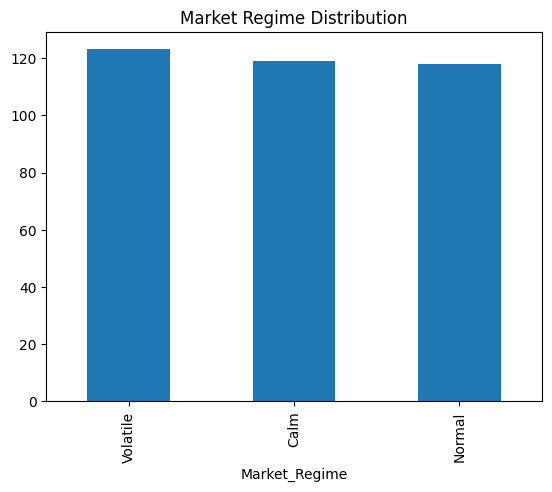

In [9]:
data["Market_Regime"].value_counts().plot(
    kind="bar"
)

plt.title("Market Regime Distribution")

plt.show()

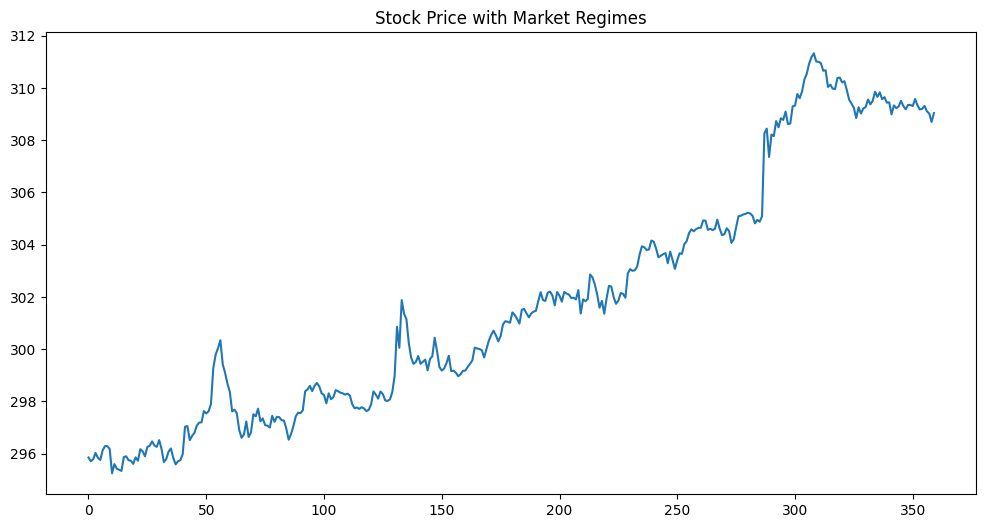

In [10]:
plt.figure(figsize=(12,6))

plt.plot(data["Close"])

plt.title("Stock Price with Market Regimes")

plt.show()

In [11]:
from sklearn.cluster import KMeans

In [12]:
regime_features = data[
    ["Returns", "Volatility", "Momentum"]
]

In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

data["Regime_Cluster"] = kmeans.fit_predict(
    regime_features
)

In [14]:
data.to_csv(
    "../data/aapl_regime_dataset.csv",
    index=False
)